In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('/content/heart.csv')
df.shape

(1025, 14)

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212,0,1,168.0,0,1.0,2,2,3,0
1,53,1,0,140.0,203,1,0,155.0,1,3.1,0,0,3,0
2,70,1,0,145.0,174,0,1,125.0,1,2.6,0,0,3,0
3,61,1,0,148.0,203,0,1,161.0,0,0.0,2,1,3,0
4,62,0,0,138.0,294,1,1,106.0,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140.0,221,0,1,164.0,1,0.0,2,0,2,1
1021,60,1,0,125.0,258,0,0,141.0,1,2.8,1,1,3,0
1022,47,1,0,110.0,275,0,0,118.0,1,1.0,1,1,2,0
1023,50,0,0,110.0,254,0,0,159.0,0,0.0,2,0,2,1


In [ ]:
df = df.dropna()
df.shape

(1023, 14)

In [ ]:
y=df['target']
x=df.drop(columns=['target'])

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)




In [ ]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train_scaled,y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred=model.predict(x_test_scaled)


In [ ]:
feature_importance = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_[0]})

feature_importance['abs_coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)



In [ ]:
y_prob = model.predict_proba(x_test_scaled)[:, 1]

count_high_prob = (y_prob > 0.9).sum()
count_high_prob, len(y_prob)
y_prob

array([0.9775237 , 0.99435255, 0.61551665, 0.01546806, 0.00404214,
       0.00491457, 0.73733893, 0.04795894, 0.730723  , 0.53697134,
       0.98219334, 0.07059948, 0.06800562, 0.87644934, 0.45388521,
       0.90093108, 0.96535287, 0.92124395, 0.91433212, 0.90901699,
       0.63328601, 0.85554263, 0.94502532, 0.81207031, 0.83751187,
       0.26744143, 0.95185084, 0.00343874, 0.10388884, 0.10722806,
       0.00158816, 0.49882652, 0.14757509, 0.99435255, 0.00568459,
       0.99212651, 0.86681341, 0.96352135, 0.98247144, 0.98465248,
       0.72489027, 0.95263241, 0.60440846, 0.53698191, 0.00372988,
       0.06800562, 0.05600546, 0.36027946, 0.9763401 , 0.39036218,
       0.75639342, 0.02483756, 0.92447931, 0.98782038, 0.97719677,
       0.99317366, 0.62716775, 0.00717398, 0.68533853, 0.12956892,
       0.12296553, 0.00517902, 0.14997159, 0.8459461 , 0.95185084,
       0.03953046, 0.98112625, 0.9763401 , 0.78135439, 0.21959941,
       0.48883167, 0.58332217, 0.38069911, 0.64576642, 0.26797

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

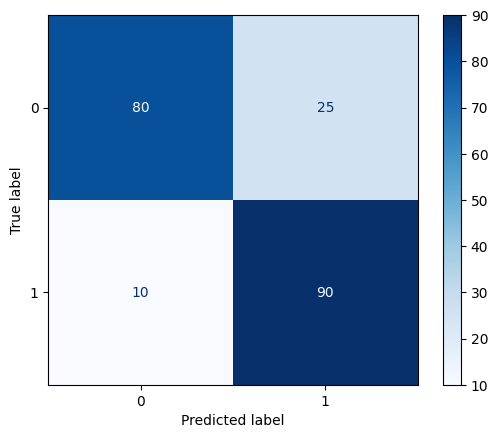

In [ ]:
cm = confusion_matrix(y_test, y_pred,)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.show()





In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9101904761904761


In [ ]:
from sklearn.metrics import recall_score, precision_score
recall = recall_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
recall


0.9

In [ ]:
precision

0.782608695652174